# **Project: Data Quality & Governance Monitoring Dashboard**



# Installing required libraries

In [1]:
%pip install pandas numpy openpyxl matplotlib seaborn


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


# Loading the Excel dataset

In [5]:
file_path = r"/content/raw_online_retail.csv.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully
Number of rows: 541909
Number of columns: 8


# Creating a backup

In [6]:
df_original = df.copy()

print("Original backup created")

Original backup created


# Inspect the dataset

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [10]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

# Standardize column names

In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

# Checking data types

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [14]:
df["invoicedate"] = pd.to_datetime(
    df["invoicedate"],
    errors="coerce"
)

In [16]:
df["quantity"] = pd.to_numeric(
    df["quantity"],
    errors="coerce"
)

df["unitprice"] = pd.to_numeric(
    df["unitprice"],
    errors="coerce"
)

df["customerid"] = pd.to_numeric(
    df["customerid"],
    errors="coerce"
)

# Creating the initial data-quality report of project

In [17]:
quality_report = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "total_rows": len(df),
    "missing_values": df.isnull().sum().values,
    "missing_percentage": (
        df.isnull().mean().values * 100
    ).round(2),
    "unique_values": df.nunique().values
})

quality_report

,column_name,data_type,total_rows,missing_values,missing_percentage,unique_values
0,invoiceno,object,541909,0,0.00,25900
1,stockcode,object,541909,0,0.00,4070
2,description,object,541909,1454,0.27,4223
3,quantity,int64,541909,0,0.00,722
4,invoicedate,datetime64[ns],541909,0,0.00,23260
5,unitprice,float64,541909,0,0.00,1630
6,customerid,float64,541909,135080,24.93,4372
7,country,object,541909,0,0.00,38


Saving the file

In [18]:
quality_report.to_csv(
    "01_initial_data_quality_report.csv",
    index=False
)

# Checking the duplicate records

In [19]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:",
      round(duplicate_count / len(df) * 100, 2), "%")

##Display duplicate rows##
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

duplicates.head(20)

Duplicate rows: 5268
Duplicate percentage: 0.97 %


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


# Checking missing values

In [20]:
missing_report = pd.DataFrame({
    "column_name": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percentage": (
        df.isnull().mean().values * 100
    ).round(2)
})

missing_report = missing_report.sort_values(
    by="missing_count",
    ascending=False
)

missing_report

,column_name,missing_count,missing_percentage
6,customerid,135080,24.93
2,description,1454,0.27
1,stockcode,0,0.00
0,invoiceno,0,0.00
3,quantity,0,0.00
4,invoicedate,0,0.00
5,unitprice,0,0.00
7,country,0,0.00


# Visualizing  missing values:

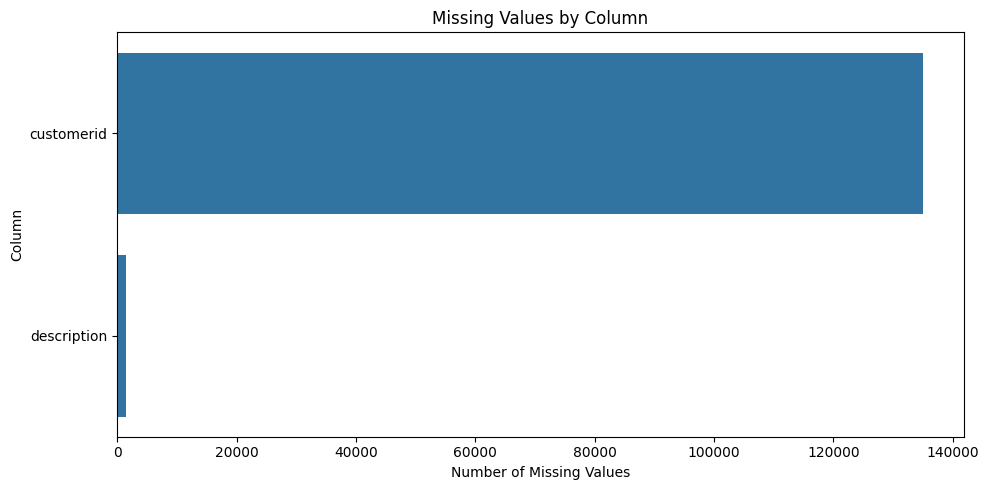

In [21]:
plt.figure(figsize=(10, 5))

missing_report_plot = missing_report[
    missing_report["missing_count"] > 0
]

sns.barplot(
    data=missing_report_plot,
    x="missing_count",
    y="column_name"
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# Checking invalid quantities and prices

In [23]:
invalid_quantity_count = (df["quantity"] <= 0).sum()
invalid_price_count = (df["unitprice"] < 0).sum()
zero_price_count = (df["unitprice"] == 0).sum()

print("Quantity less than or equal to zero:",
      invalid_quantity_count)

print("Negative unit prices:",
      invalid_price_count)

print("Zero unit prices:",
      zero_price_count)

Quantity less than or equal to zero: 10624
Negative unit prices: 2
Zero unit prices: 2515


In [24]:
invalid_quantity_rows = df[df["quantity"] <= 0]

invalid_quantity_rows.head(20)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [26]:
invalid_price_rows = df[df["unitprice"] < 0]

invalid_price_rows.head(20)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Identify cancelled invoices

In [28]:
df["invoiceno"] = df["invoiceno"].astype(str).str.strip()

df["is_cancelled"] = df["invoiceno"].str.upper().str.startswith("C")

print("Cancelled rows:", df["is_cancelled"].sum())
print("Cancelled percentage:",
      round(df["is_cancelled"].mean() * 100, 2), "%")

Cancelled rows: 9288
Cancelled percentage: 1.71 %


In [29]:
cancellation_report = (
    df["is_cancelled"]
    .value_counts()
    .rename_axis("is_cancelled")
    .reset_index(name="row_count")
)

cancellation_report

,is_cancelled,row_count
0,False,532621
1,True,9288


Check invalid descriptions

In [30]:
missing_description_count = df["description"].isnull().sum()
blank_description_count = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Missing descriptions:", missing_description_count)
print("Blank descriptions:", blank_description_count)

Missing descriptions: 1454
Blank descriptions: 1454


Check invalid customer IDs

In [31]:
missing_customer_count = df["customerid"].isnull().sum()

print("Missing Customer IDs:", missing_customer_count)
print("Missing Customer ID percentage:",
      round(missing_customer_count / len(df) * 100, 2), "%")

Missing Customer IDs: 135080
Missing Customer ID percentage: 24.93 %


Check invalid dates

In [33]:
invalid_date_count = df["invoicedate"].isnull().sum()

print("Invalid dates:", invalid_date_count)

##Check the date range:
print("Minimum invoice date:", df["invoicedate"].min())
print("Maximum invoice date:", df["invoicedate"].max())

Invalid dates: 0
Minimum invoice date: 2010-12-01 08:26:00
Maximum invoice date: 2011-12-09 12:50:00


Create a complete data-quality rules report

In [35]:
total_rows = len(df)

data_quality_rules = pd.DataFrame([
    {
        "rule_id": "DQ001",
        "rule_name": "Missing Description",
        "issue_count": df["description"].isnull().sum(),
        "issue_percentage": round(
            df["description"].isnull().mean() * 100, 2
        ),
        "severity": "Medium"
    },
    {
        "rule_id": "DQ002",
        "rule_name": "Missing Customer ID",
        "issue_count": df["customerid"].isnull().sum(),
        "issue_percentage": round(
            df["customerid"].isnull().mean() * 100, 2
        ),
        "severity": "Medium"
    },
    {
        "rule_id": "DQ003",
        "rule_name": "Duplicate Records",
        "issue_count": df.duplicated().sum(),
        "issue_percentage": round(
            df.duplicated().mean() * 100, 2
        ),
        "severity": "High"
    },
    {
        "rule_id": "DQ004",
        "rule_name": "Invalid Quantity",
        "issue_count": (df["quantity"] <= 0).sum(),
        "issue_percentage": round(
            (df["quantity"] <= 0).mean() * 100, 2
        ),
        "severity": "High"
    },
    {
        "rule_id": "DQ005",
        "rule_name": "Zero Unit Price",
        "issue_count": (df["unitprice"] == 0).sum(),
        "issue_percentage": round(
            (df["unitprice"] == 0).mean() * 100, 2
        ),
        "severity": "Medium"
    },
    {
        "rule_id": "DQ006",
        "rule_name": "Invalid Invoice Date",
        "issue_count": df["invoicedate"].isnull().sum(),
        "issue_percentage": round(
            df["invoicedate"].isnull().mean() * 100, 2
        ),
        "severity": "High"
    },
    {
        "rule_id": "DQ007",
        "rule_name": "Cancelled Invoice",
        "issue_count": df["is_cancelled"].sum(),
        "issue_percentage": round(
            df["is_cancelled"].mean() * 100, 2
        ),
        "severity": "Informational"
    }
])

data_quality_rules

,rule_id,rule_name,issue_count,issue_percentage,severity
0,DQ001,Missing Description,1454,0.27,Medium
1,DQ002,Missing Customer ID,135080,24.93,Medium
2,DQ003,Duplicate Records,5268,0.97,High
3,DQ004,Invalid Quantity,10624,1.96,High
4,DQ005,Zero Unit Price,2515,0.46,Medium
5,DQ006,Invalid Invoice Date,0,0.00,High
6,DQ007,Cancelled Invoice,9288,1.71,Informational


In [36]:
data_quality_rules.to_csv(
    "02_data_quality_rules_report.csv",
    index=False
)

Create a cleaned dataset

In [37]:
df_clean = df.drop_duplicates().copy()

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Removed duplicates:", len(df) - len(df_clean))

Rows before removing duplicates: 541909
Rows after removing duplicates: 536641
Removed duplicates: 5268


In [38]:
df_clean = df_clean[
    df_clean["description"].notna()
].copy()

In [40]:
df_clean = df_clean[
    df_clean["invoicedate"].notna()
].copy()

In [42]:
df_clean["is_valid_sale"] = (
    (df_clean["quantity"] > 0) &
    (df_clean["unitprice"] > 0) &
    (df_clean["customerid"].notna()) &
    (df_clean["is_cancelled"] == False)
)

df_sales = df_clean[
    df_clean["is_valid_sale"]
].copy()

print("Cleaned sales rows:", len(df_sales))

Cleaned sales rows: 392692


# Create business metrics

In [44]:
df_sales["sales_amount"] = (
    df_sales["quantity"] *
    df_sales["unitprice"]
)

In [46]:
df_sales["invoice_year"] = df_sales["invoicedate"].dt.year
df_sales["invoice_month"] = df_sales["invoicedate"].dt.month
df_sales["month_name"] = df_sales["invoicedate"].dt.strftime("%b")
df_sales["invoice_day"] = df_sales["invoicedate"].dt.date

In [47]:
df_sales.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,is_cancelled,is_valid_sale,sales_amount,invoice_year,invoice_month,month_name,invoice_day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,True,15.30,2010,12,Dec,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,True,20.34,2010,12,Dec,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,True,22.00,2010,12,Dec,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,True,20.34,2010,12,Dec,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,True,20.34,2010,12,Dec,2010-12-01


# Create KPI summary

In [49]:
kpi_summary = pd.DataFrame({
    "metric": [
        "Total Raw Rows",
        "Total Clean Sales Rows",
        "Total Revenue",
        "Total Quantity Sold",
        "Unique Invoices",
        "Unique Customers",
        "Unique Products",
        "Duplicate Rows",
        "Missing Customer IDs",
        "Cancelled Rows"
    ],
    "value": [
        len(df),
        len(df_sales),
        round(df_sales["sales_amount"].sum(), 2),
        df_sales["quantity"].sum(),
        df_sales["invoiceno"].nunique(),
        df_sales["customerid"].nunique(),
        df_sales["stockcode"].nunique(),
        df.duplicated().sum(),
        df["customerid"].isnull().sum(),
        df["is_cancelled"].sum()
    ]
})

kpi_summary

,metric,value
0,Total Raw Rows,541909.00
1,Total Clean Sales Rows,392692.00
2,Total Revenue,8887208.89
3,Total Quantity Sold,5152002.00
4,Unique Invoices,18532.00
5,Unique Customers,4338.00
6,Unique Products,3665.00
7,Duplicate Rows,5268.00
8,Missing Customer IDs,135080.00
9,Cancelled Rows,9288.00


In [50]:
kpi_summary.to_csv(
    "03_kpi_summary.csv",
    index=False
)

# Create monthly revenue analysis

In [52]:
monthly_revenue = (
    df_sales
    .groupby(
        df_sales["invoicedate"].dt.to_period("M")
    )["sales_amount"]
    .sum()
    .reset_index()
)

monthly_revenue["invoicedate"] = (
    monthly_revenue["invoicedate"]
    .astype(str)
)

monthly_revenue

,invoicedate,sales_amount
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


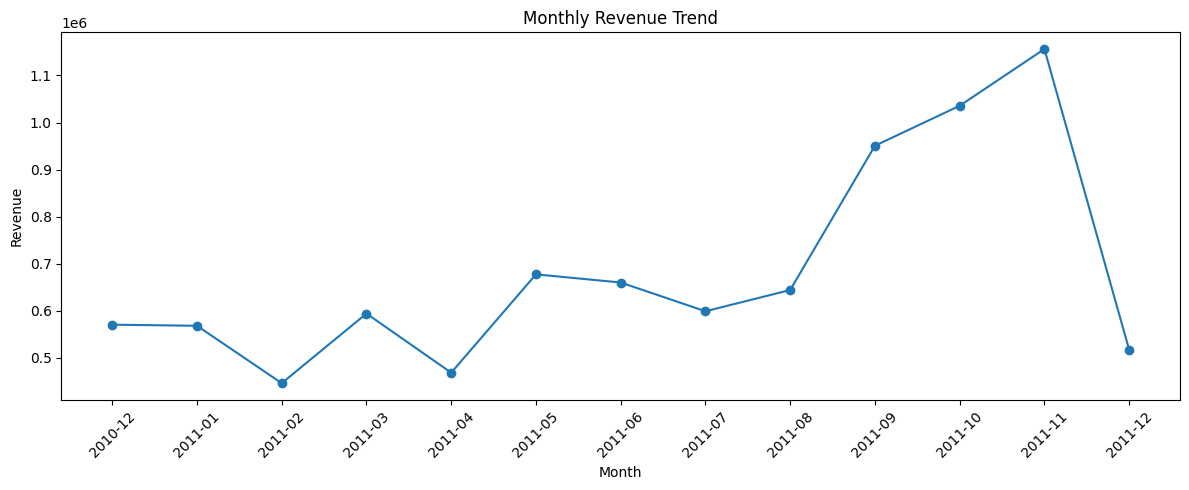

In [54]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["invoicedate"],
    monthly_revenue["sales_amount"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Creating country-level analysis

In [55]:
country_revenue = (
    df_sales
    .groupby("country")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(15)

,country,sales_amount
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


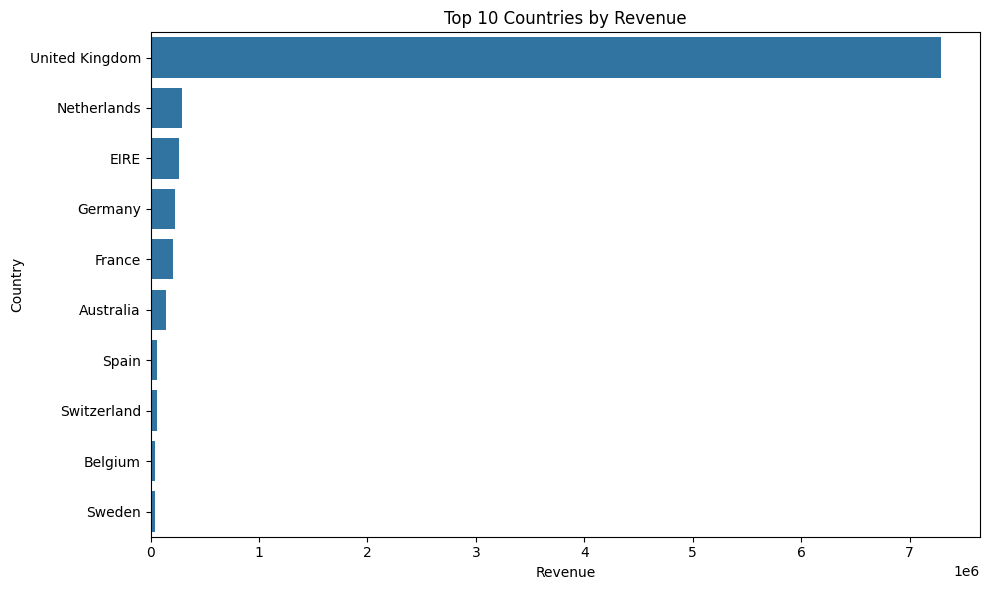

In [56]:
top_10_countries = country_revenue.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_countries,
    x="sales_amount",
    y="country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Create product-level analysis

In [58]:
product_revenue = (
    df_sales
    .groupby(
        ["stockcode", "description"],
        dropna=False
    )["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_revenue.head(20)

,stockcode,description,sales_amount
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142264.75
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,85099B,JUMBO BAG RED RETROSPOT,85040.54
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POST,POSTAGE,77803.96
6,47566,PARTY BUNTING,68785.23
7,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,M,Manual,53419.93
9,23084,RABBIT NIGHT LIGHT,51251.24


# Create customer-level analysis

In [59]:
customer_revenue = (
    df_sales
    .groupby("customerid")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_revenue.head(20)

,customerid,sales_amount
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


# Create data-quality trend by month

In [61]:
df["quality_month"] = df["invoicedate"].dt.to_period("M").astype(str)

monthly_quality = (
    df.groupby("quality_month")
    .agg(
        total_rows=("invoiceno", "size"),
        missing_customer_ids=("customerid", lambda x: x.isnull().sum()),
        missing_descriptions=("description", lambda x: x.isnull().sum()),
        duplicate_rows=("invoiceno", lambda x: 0),
        invalid_quantities=("quantity", lambda x: (x <= 0).sum()),
        cancelled_rows=("is_cancelled", "sum")
    )
    .reset_index()
)

monthly_quality

,quality_month,total_rows,missing_customer_ids,missing_descriptions,duplicate_rows,invalid_quantities,cancelled_rows
0,2010-12,42481,15631,125,0,798,728
1,2011-01,35147,13235,114,0,797,701
2,2011-02,27707,7344,65,0,523,475
3,2011-03,36748,8926,165,0,833,699
4,2011-04,29916,6718,226,0,745,559
5,2011-05,37030,8122,138,0,738,621
6,2011-06,36874,9038,91,0,818,711
7,2011-07,39518,12016,155,0,802,685
8,2011-08,35284,7622,82,0,718,668
9,2011-09,50226,9404,99,0,903,805


In [62]:
monthly_quality["missing_customer_pct"] = (
    monthly_quality["missing_customer_ids"] /
    monthly_quality["total_rows"] * 100
).round(2)

monthly_quality["invalid_quantity_pct"] = (
    monthly_quality["invalid_quantities"] /
    monthly_quality["total_rows"] * 100
).round(2)

monthly_quality

,quality_month,total_rows,missing_customer_ids,missing_descriptions,duplicate_rows,invalid_quantities,cancelled_rows,missing_customer_pct,invalid_quantity_pct
0,2010-12,42481,15631,125,0,798,728,36.80,1.88
1,2011-01,35147,13235,114,0,797,701,37.66,2.27
2,2011-02,27707,7344,65,0,523,475,26.51,1.89
3,2011-03,36748,8926,165,0,833,699,24.29,2.27
4,2011-04,29916,6718,226,0,745,559,22.46,2.49
5,2011-05,37030,8122,138,0,738,621,21.93,1.99
6,2011-06,36874,9038,91,0,818,711,24.51,2.22
7,2011-07,39518,12016,155,0,802,685,30.41,2.03
8,2011-08,35284,7622,82,0,718,668,21.60,2.03
9,2011-09,50226,9404,99,0,903,805,18.72,1.80


In [63]:
monthly_quality.to_csv(
    "04_monthly_quality_trend.csv",
    index=False
)

# Create a data-quality score

In [64]:
total_rows = len(df)

missing_customer_pct = df["customerid"].isnull().mean() * 100
missing_description_pct = df["description"].isnull().mean() * 100
duplicate_pct = df.duplicated().mean() * 100
invalid_quantity_pct = (df["quantity"] <= 0).mean() * 100

overall_issue_percentage = np.mean([
    missing_customer_pct,
    missing_description_pct,
    duplicate_pct,
    invalid_quantity_pct
])

data_quality_score = max(
    0,
    round(100 - overall_issue_percentage, 2)
)

print("Data Quality Score:", data_quality_score, "/ 100")

Data Quality Score: 92.97 / 100


In [65]:
quality_score_summary = pd.DataFrame({
    "metric": [
        "Missing Customer ID %",
        "Missing Description %",
        "Duplicate Rows %",
        "Invalid Quantity %",
        "Overall Data Quality Score"
    ],
    "value": [
        round(missing_customer_pct, 2),
        round(missing_description_pct, 2),
        round(duplicate_pct, 2),
        round(invalid_quantity_pct, 2),
        data_quality_score
    ]
})

quality_score_summary

,metric,value
0,Missing Customer ID %,24.93
1,Missing Description %,0.27
2,Duplicate Rows %,0.97
3,Invalid Quantity %,1.96
4,Overall Data Quality Score,92.97


In [66]:
quality_score_summary.to_csv(
    "05_data_quality_score.csv",
    index=False
)

Exporting cleaned datasets

In [67]:
df_clean.to_csv(
    "online_retail_cleaned_with_flags.csv",
    index=False
)

df_sales.to_csv(
    "online_retail_valid_sales.csv",
    index=False
)

print("Cleaned datasets exported successfully")

Cleaned datasets exported successfully


Export all dashboard tables into one Excel file

In [68]:
with pd.ExcelWriter(
    "data_quality_dashboard_tables.xlsx",
    engine="openpyxl"
) as writer:

    quality_report.to_excel(
        writer,
        sheet_name="Initial Quality",
        index=False
    )

    data_quality_rules.to_excel(
        writer,
        sheet_name="Quality Rules",
        index=False
    )

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    monthly_revenue.to_excel(
        writer,
        sheet_name="Monthly Revenue",
        index=False
    )

    country_revenue.to_excel(
        writer,
        sheet_name="Country Revenue",
        index=False
    )

    product_revenue.to_excel(
        writer,
        sheet_name="Product Revenue",
        index=False
    )

    customer_revenue.to_excel(
        writer,
        sheet_name="Customer Revenue",
        index=False
    )

    monthly_quality.to_excel(
        writer,
        sheet_name="Monthly Quality",
        index=False
    )

    quality_score_summary.to_excel(
        writer,
        sheet_name="Quality Score",
        index=False
    )

print("Excel dashboard tables created successfully")

Excel dashboard tables created successfully


# Creating a final project summary

In [69]:
project_summary = {
    "project_name": "Data Quality & Governance Monitoring Dashboard",
    "raw_rows": len(df),
    "clean_rows": len(df_clean),
    "valid_sales_rows": len(df_sales),
    "duplicate_rows": int(df.duplicated().sum()),
    "missing_customer_ids": int(df["customerid"].isnull().sum()),
    "missing_descriptions": int(df["description"].isnull().sum()),
    "invalid_quantities": int((df["quantity"] <= 0).sum()),
    "cancelled_rows": int(df["is_cancelled"].sum()),
    "total_revenue": round(df_sales["sales_amount"].sum(), 2),
    "data_quality_score": data_quality_score
}

project_summary_df = pd.DataFrame(
    list(project_summary.items()),
    columns=["metric", "value"]
)

project_summary_df

,metric,value
0,project_name,Data Quality & Governance Monitoring Dashboard
1,raw_rows,541909
2,clean_rows,535187
3,valid_sales_rows,392692
4,duplicate_rows,5268
5,missing_customer_ids,135080
6,missing_descriptions,1454
7,invalid_quantities,10624
8,cancelled_rows,9288
9,total_revenue,8887208.89


In [70]:
project_summary_df.to_csv(
    "06_final_project_summary.csv",
    index=False
)

In [ ]:
Data_Quality_Project.ipynb
01_initial_data_quality_report.csv
02_data_quality_rules_report.csv
03_kpi_summary.csv
04_monthly_quality_trend.csv
05_data_quality_score.csv
06_final_project_summary.csv
online_retail_cleaned_with_flags.csv
online_retail_valid_sales.csv
data_quality_dashboard_tables.xlsx